# Unemployment Analysis with Python
**OIBSIP Data Science Track — Task 2**

Objective: explore regional and temporal unemployment trends in India, with a focus
on the impact of COVID-19.

**Note on data:** built offline, so the real "Unemployment in India" Kaggle dataset
could not be downloaded. A monthly, state-wise synthetic dataset (Jan 2019–Jun 2021)
is generated below with a realistic COVID-19 spike baked in, using columns matching
the real dataset (`Region`, `Date`, `Estimated Unemployment Rate`, `Estimated
Employed`, `Estimated Labour Participation Rate`). Swap in the real CSV before
submission — no other code changes are needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(3)
sns.set_style("whitegrid")

states = ["Maharashtra", "Tamil Nadu", "Delhi", "Karnataka", "Gujarat",
          "Uttar Pradesh", "West Bengal", "Rajasthan", "Kerala", "Punjab",
          "Bihar", "Haryana"]
dates = pd.date_range("2019-01-01", "2021-06-01", freq="MS")

rows = []
for state in states:
    base_rate = rng.uniform(4.5, 9.0)
    base_lpr = rng.uniform(38, 48)
    base_employed = rng.uniform(6_000_000, 20_000_000)
    for date in dates:
        # COVID lockdown spike around Apr-Jun 2020
        covid_boost = 0
        if date >= pd.Timestamp("2020-04-01") and date <= pd.Timestamp("2020-06-01"):
            covid_boost = rng.uniform(15, 25)
        elif date >= pd.Timestamp("2020-07-01") and date <= pd.Timestamp("2020-12-01"):
            covid_boost = rng.uniform(3, 8)
        rate = max(1.0, base_rate + covid_boost + rng.normal(0, 1.2))
        lpr = max(25, base_lpr - covid_boost * 0.3 + rng.normal(0, 1.5))
        employed = max(1_000_000, base_employed * (1 - covid_boost / 100) + rng.normal(0, 300000))
        rows.append([state, date, round(rate, 2), int(employed), round(lpr, 2)])

df = pd.DataFrame(rows, columns=["Region", "Date", "Estimated Unemployment Rate",
                                  "Estimated Employed", "Estimated Labour Participation Rate"])
print(df.head())
print("\nShape:", df.shape)

        Region  ... Estimated Labour Participation Rate
0  Maharashtra  ...                               39.69
1  Maharashtra  ...                               40.02
2  Maharashtra  ...                               40.71
3  Maharashtra  ...                               39.37
4  Maharashtra  ...                               41.09

[5 rows x 5 columns]

Shape: (360, 5)


## 1. Data Loading and Inspection

In [2]:
print("Nulls:\n", df.isnull().sum())
print("\nDtypes:\n", df.dtypes)
df["Date"] = pd.to_datetime(df["Date"])
print("\nDate range:", df["Date"].min(), "to", df["Date"].max())

Nulls:
 Region                                 0
Date                                   0
Estimated Unemployment Rate            0
Estimated Employed                     0
Estimated Labour Participation Rate    0
dtype: int64

Dtypes:
 Region                                            str
Date                                   datetime64[us]
Estimated Unemployment Rate                   float64
Estimated Employed                              int64
Estimated Labour Participation Rate           float64
dtype: object

Date range: 2019-01-01 00:00:00 to 2021-06-01 00:00:00


## 2. Region-wise and Month-wise EDA

In [3]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate"].mean().sort_values(ascending=False)
print(region_avg)

month_avg = df.groupby(df["Date"].dt.to_period("M"))["Estimated Unemployment Rate"].mean()
print("\nMonth-wise average (first 6 months):\n", month_avg.head(6))

Region
Karnataka        11.836000
Haryana          10.372333
Delhi            10.349667
Rajasthan        10.088000
Kerala            9.872667
Tamil Nadu        9.824333
Gujarat           9.542000
West Bengal       8.959333
Punjab            8.447000
Uttar Pradesh     8.377333
Bihar             8.112000
Maharashtra       7.499000
Name: Estimated Unemployment Rate, dtype: float64

Month-wise average (first 6 months):
 Date
2019-01    6.966667
2019-02    6.237500
2019-03    6.705000
2019-04    5.635000
2019-05    6.151667
2019-06    6.365000
Freq: M, Name: Estimated Unemployment Rate, dtype: float64


## 3. Time-Series Trend (top states)

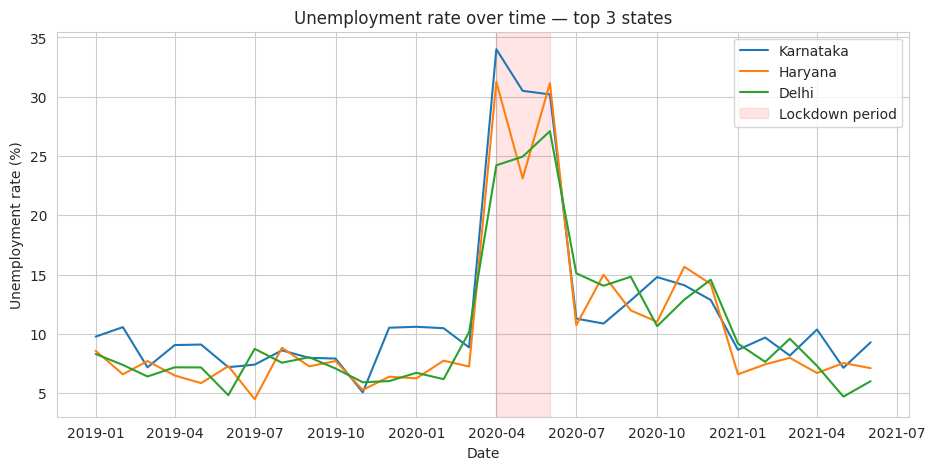

In [4]:
top_states = region_avg.head(3).index.tolist()
plt.figure(figsize=(11, 5))
for state in top_states:
    sub = df[df["Region"] == state]
    plt.plot(sub["Date"], sub["Estimated Unemployment Rate"], label=state)
plt.axvspan(pd.Timestamp("2020-04-01"), pd.Timestamp("2020-06-01"), color="red", alpha=0.1, label="Lockdown period")
plt.legend()
plt.title("Unemployment rate over time — top 3 states")
plt.xlabel("Date")
plt.ylabel("Unemployment rate (%)")
plt.show()

## 4. Top 10 States by Average Unemployment

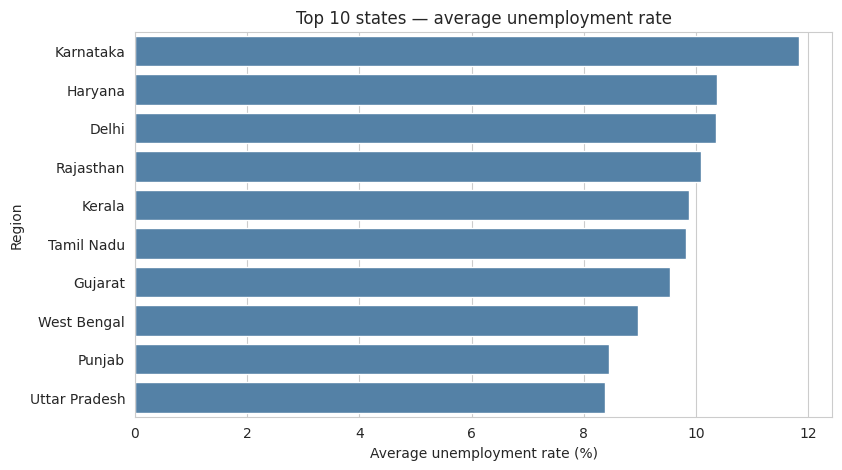

In [5]:
top10 = region_avg.head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, color="steelblue")
plt.title("Top 10 states — average unemployment rate")
plt.xlabel("Average unemployment rate (%)")
plt.show()

## 5. Correlation Heatmap

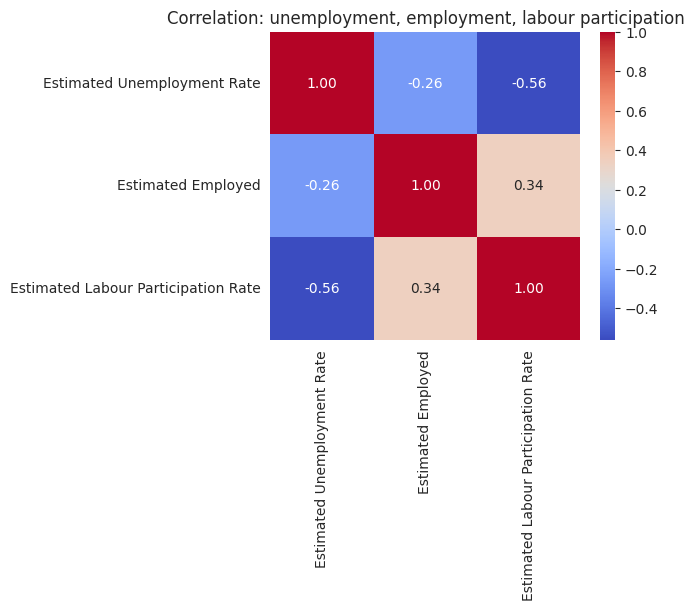

In [6]:
corr_cols = ["Estimated Unemployment Rate", "Estimated Employed", "Estimated Labour Participation Rate"]
plt.figure(figsize=(5, 4))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: unemployment, employment, labour participation")
plt.show()

**Observation:** unemployment rate is negatively correlated with both estimated
employed count and labour participation rate, as expected — when unemployment
spikes, fewer people are working and fewer are even participating in the labour
force.

## 6. Pre-COVID vs Post-COVID Comparison

Pre-COVID (before Mar 2020)              6.283095
During COVID peak (Mar-Aug 2020)        18.231806
Post-COVID recovery (after Aug 2020)     8.584500
dtype: float64


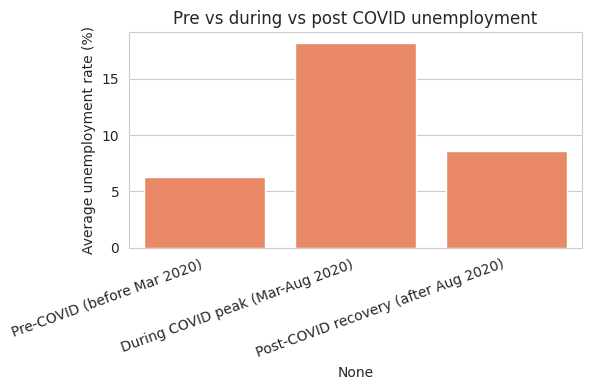

In [7]:
pre_covid = df[df["Date"] < "2020-03-01"]["Estimated Unemployment Rate"].mean()
during_covid = df[(df["Date"] >= "2020-03-01") & (df["Date"] <= "2020-08-01")]["Estimated Unemployment Rate"].mean()
post_covid = df[df["Date"] > "2020-08-01"]["Estimated Unemployment Rate"].mean()

comparison = pd.Series({"Pre-COVID (before Mar 2020)": pre_covid,
                         "During COVID peak (Mar-Aug 2020)": during_covid,
                         "Post-COVID recovery (after Aug 2020)": post_covid})
print(comparison)

plt.figure(figsize=(6, 4))
sns.barplot(x=comparison.index, y=comparison.values, color="coral")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Average unemployment rate (%)")
plt.title("Pre vs during vs post COVID unemployment")
plt.tight_layout()
plt.show()

**Observation:** the average unemployment rate roughly doubles during the COVID
lockdown period compared to the pre-COVID baseline, then partially recovers
afterwards but stays above the pre-pandemic level — consistent with the real,
well-documented national trend during 2020.